In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    mean_squared_error, r2_score, roc_auc_score, roc_curve
)

plt.rcParams['figure.dpi'] = 120
print("All libraries loaded ✅")

All libraries loaded ✅


In [2]:
df = pd.read_csv('heart.csv')
print(f"Shape: {df.shape}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nTarget distribution:\n{df['HeartDisease'].value_counts()}")
print(f"\nDisease rate: {df['HeartDisease'].mean()*100:.1f}%")
df.head(10)

Shape: (918, 12)

Missing values:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

Target distribution:
HeartDisease
1    508
0    410
Name: count, dtype: int64

Disease rate: 55.3%


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208,0,Normal,142,N,0.0,Up,0
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1
9,48,F,ATA,120,284,0,Normal,120,N,0.0,Up,0


In [25]:
df_enc = df.copy()
cat_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
le = LabelEncoder()
for col in cat_cols:
    df_enc[col] = le.fit_transform(df_enc[col])

X = df_enc.drop('HeartDisease', axis=1)
y = df_enc['HeartDisease']
feature_names = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Features: {feature_names}")

Train: (642, 11) | Test: (276, 11)
Features: ['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope']


In [26]:
dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print(f"Decision Tree Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
print()
print(classification_report(y_test, y_pred_dt, target_names=['No Disease', 'Disease']))

Decision Tree Accuracy: 0.8370

              precision    recall  f1-score   support

  No Disease       0.81      0.79      0.80       112
     Disease       0.86      0.87      0.86       164

    accuracy                           0.84       276
   macro avg       0.83      0.83      0.83       276
weighted avg       0.84      0.84      0.84       276



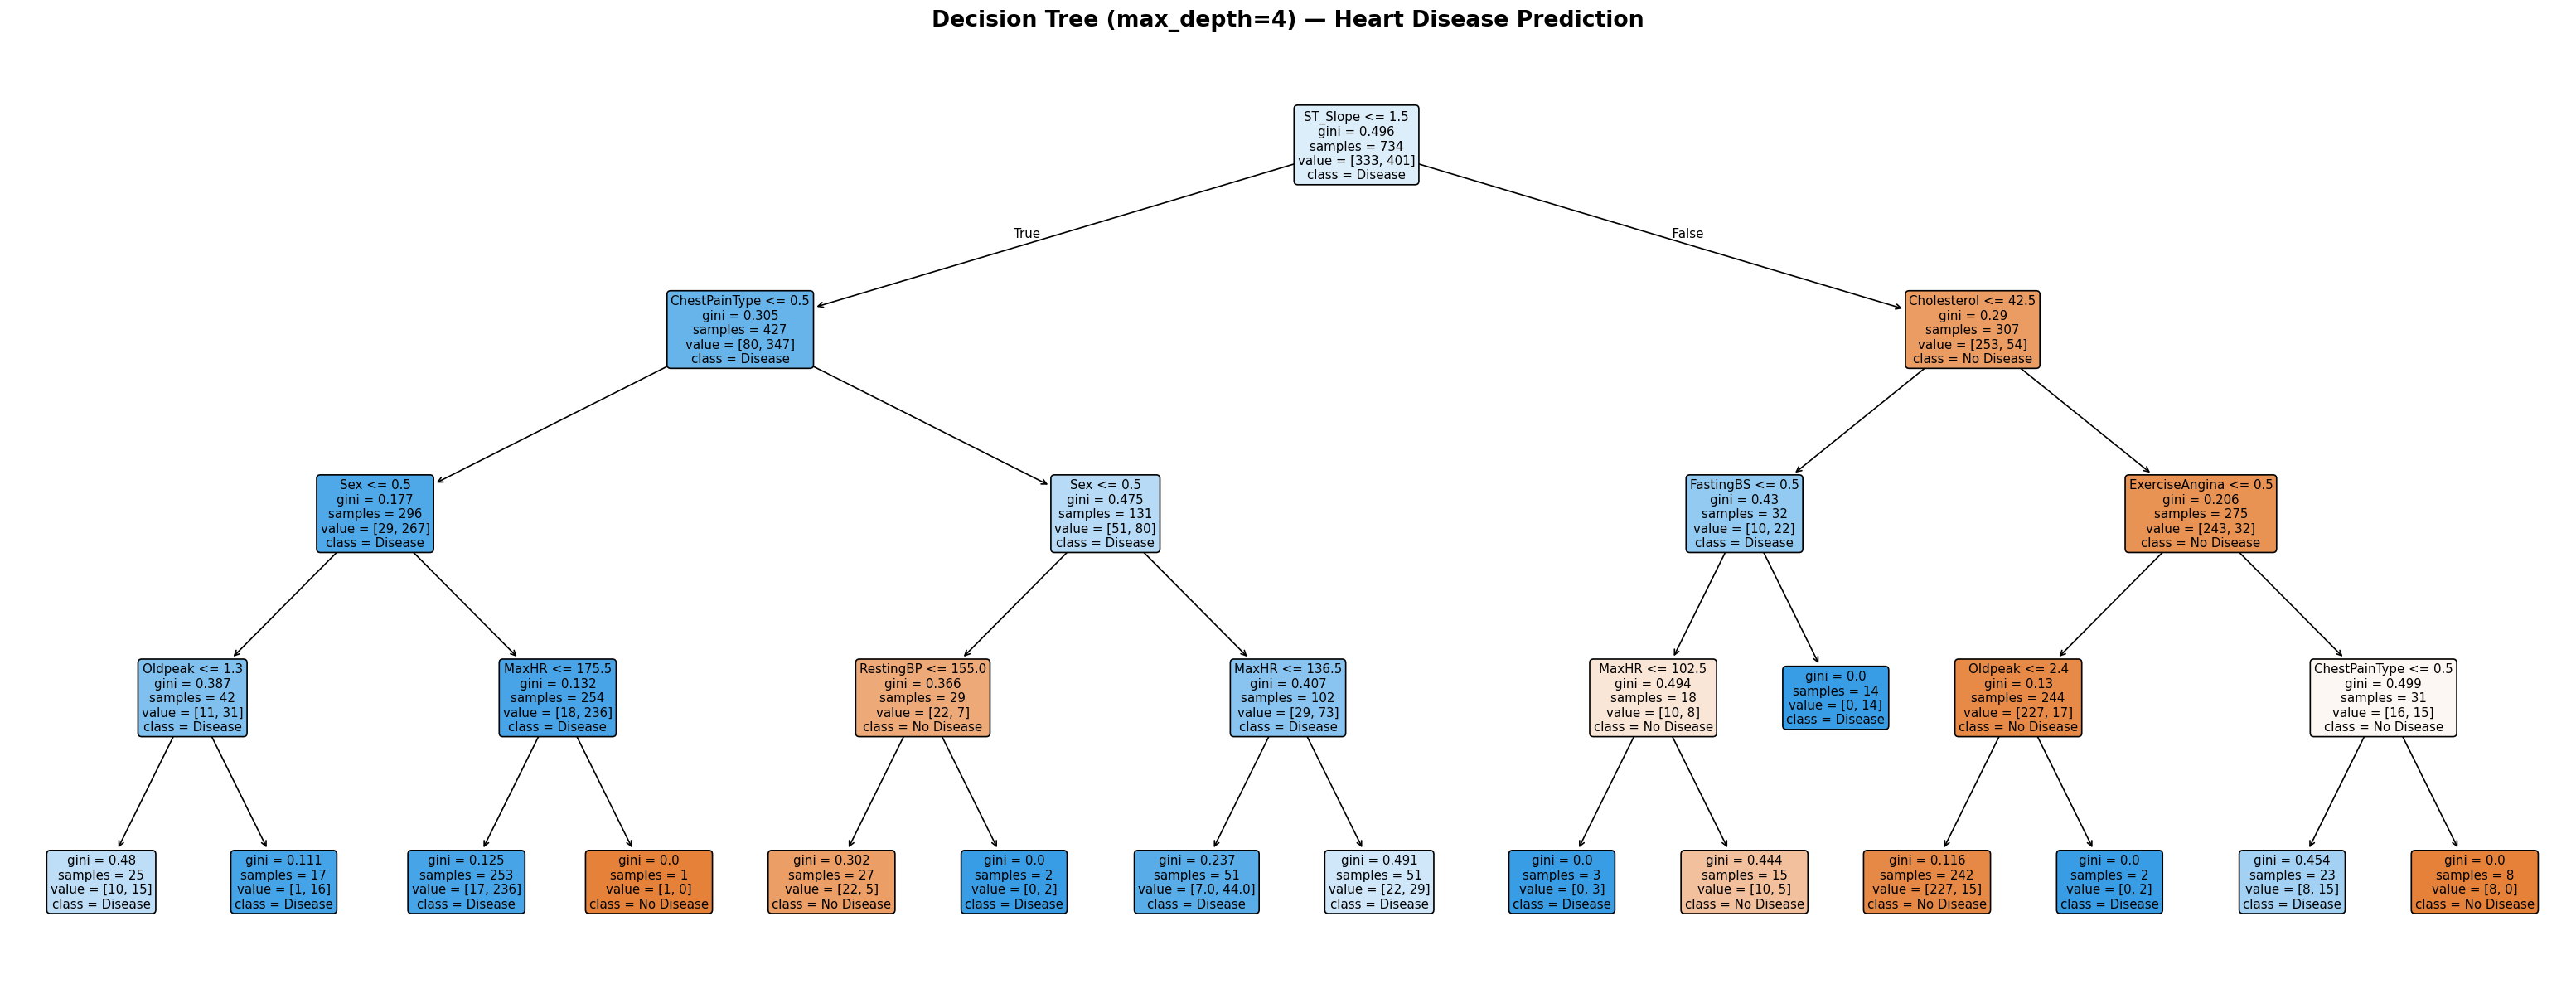

Blue nodes → No Disease | Orange nodes → Disease


In [6]:
fig, ax = plt.subplots(figsize=(26, 10))
plot_tree(dt,
          feature_names=feature_names,
          class_names=['No Disease', 'Disease'],
          filled=True,
          rounded=True,
          fontsize=9,
          ax=ax)
ax.set_title('Decision Tree (max_depth=4) — Heart Disease Prediction',
             fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()
print("Blue nodes → No Disease | Orange nodes → Disease")

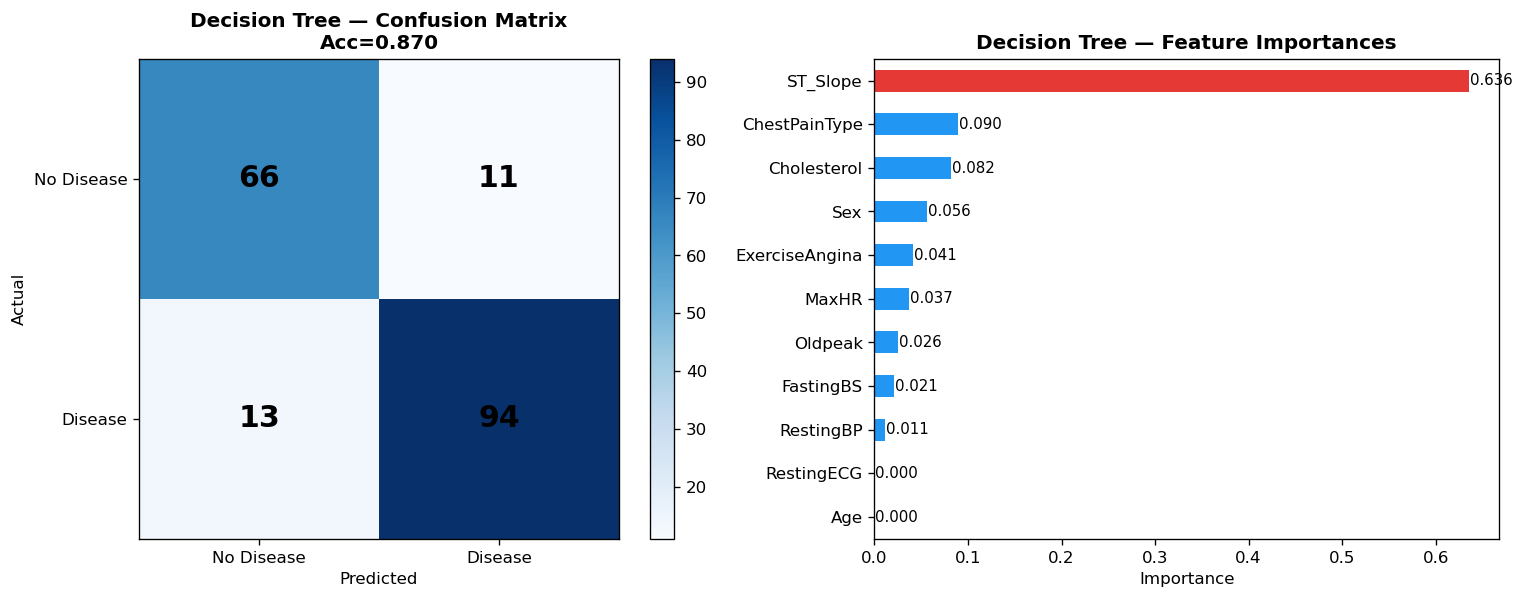

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred_dt)
im = axes[0].imshow(cm, cmap='Blues')
plt.colorbar(im, ax=axes[0])
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, str(cm[i, j]),
                     ha='center', va='center',
                     fontsize=18, fontweight='bold', color='black')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['No Disease', 'Disease'])
axes[0].set_yticks([0, 1])
axes[0].set_yticklabels(['No Disease', 'Disease'])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title(f'Decision Tree — Confusion Matrix\nAcc={accuracy_score(y_test, y_pred_dt):.3f}',
                  fontweight='bold')

# --- Feature Importance ---
imp = pd.Series(dt.feature_importances_, index=feature_names).sort_values(ascending=True)
bar_colors = ['#2196F3' if v < imp.max() * 0.5 else '#E53935' for v in imp]
imp.plot(kind='barh', ax=axes[1], color=bar_colors)
axes[1].set_title('Decision Tree — Feature Importances', fontweight='bold')
axes[1].set_xlabel('Importance')
for i, v in enumerate(imp):
    axes[1].text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

In [8]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr_raw = lr.predict(X_test)
y_pred_lr = (y_pred_lr_raw >= 0.5).astype(int)

lr_mse = mean_squared_error(y_test, y_pred_lr_raw)
lr_r2  = r2_score(y_test, y_pred_lr_raw)
lr_acc = accuracy_score(y_test, y_pred_lr)

print(f"MSE             : {lr_mse:.4f}")
print(f"R²              : {lr_r2:.4f}")
print(f"Accuracy (≥0.5) : {lr_acc:.4f}")
print()
print(classification_report(y_test, y_pred_lr, target_names=['No Disease', 'Disease']))

MSE             : 0.1373
R²              : 0.4358
Accuracy (≥0.5) : 0.8370

              precision    recall  f1-score   support

  No Disease       0.77      0.87      0.82        77
     Disease       0.90      0.81      0.85       107

    accuracy                           0.84       184
   macro avg       0.83      0.84      0.84       184
weighted avg       0.84      0.84      0.84       184



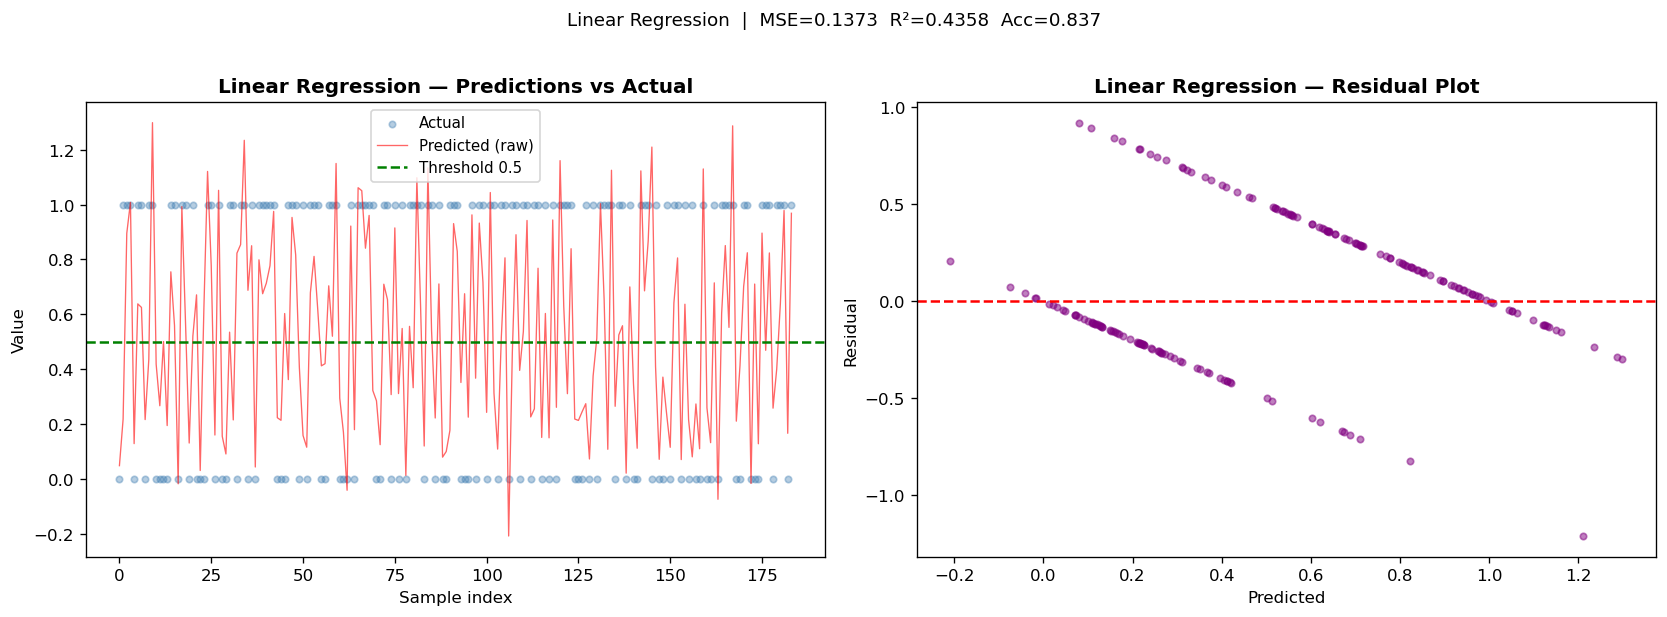

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Predictions vs Actual ---
axes[0].scatter(range(len(y_test)), y_test.values,
                alpha=0.4, label='Actual', s=15, color='steelblue')
axes[0].plot(range(len(y_test)), y_pred_lr_raw,
             color='red', alpha=0.6, label='Predicted (raw)', lw=0.8)
axes[0].axhline(0.5, color='green', linestyle='--', label='Threshold 0.5')
axes[0].set_title('Linear Regression — Predictions vs Actual', fontweight='bold')
axes[0].set_xlabel('Sample index')
axes[0].set_ylabel('Value')
axes[0].legend(fontsize=9)

# --- Residuals ---
residuals = y_test.values - y_pred_lr_raw
axes[1].scatter(y_pred_lr_raw, residuals, alpha=0.5, color='purple', s=15)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('Linear Regression — Residual Plot', fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Residual')

plt.suptitle(f'Linear Regression  |  MSE={lr_mse:.4f}  R²={lr_r2:.4f}  Acc={lr_acc:.3f}',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

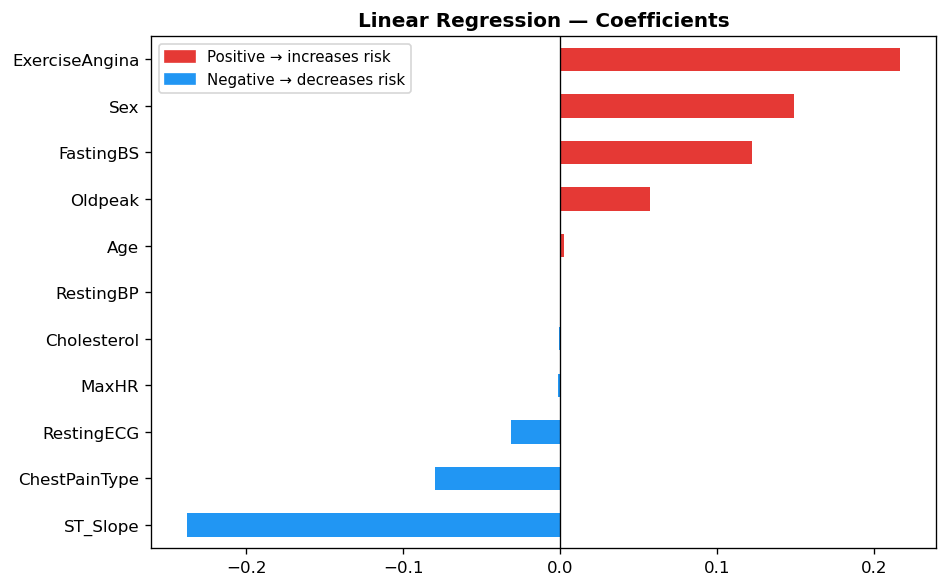

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
coef = pd.Series(lr.coef_, index=feature_names).sort_values()
bar_colors = ['#E53935' if c > 0 else '#2196F3' for c in coef]
coef.plot(kind='barh', ax=ax, color=bar_colors)
ax.axvline(0, color='black', lw=0.8)
red_p  = mpatches.Patch(color='#E53935', label='Positive → increases risk')
blue_p = mpatches.Patch(color='#2196F3', label='Negative → decreases risk')
ax.legend(handles=[red_p, blue_p], fontsize=9)
ax.set_title('Linear Regression — Coefficients', fontweight='bold')
plt.tight_layout()
plt.show()

In [31]:
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train, y_train)
y_pred_log = logreg.predict(X_test)
y_prob_log = logreg.predict_proba(X_test)[:, 1]

log_acc = accuracy_score(y_test, y_pred_log)
log_auc = roc_auc_score(y_test, y_prob_log)

print(f"Accuracy : {log_acc:.4f}")
print(f"AUC-ROC  : {log_auc:.4f}")
print()
print(classification_report(y_test, y_pred_log, target_names=['No Disease', 'Disease']))

Accuracy : 0.8623
AUC-ROC  : 0.9276

              precision    recall  f1-score   support

  No Disease       0.79      0.89      0.84       112
     Disease       0.92      0.84      0.88       164

    accuracy                           0.86       276
   macro avg       0.86      0.87      0.86       276
weighted avg       0.87      0.86      0.86       276



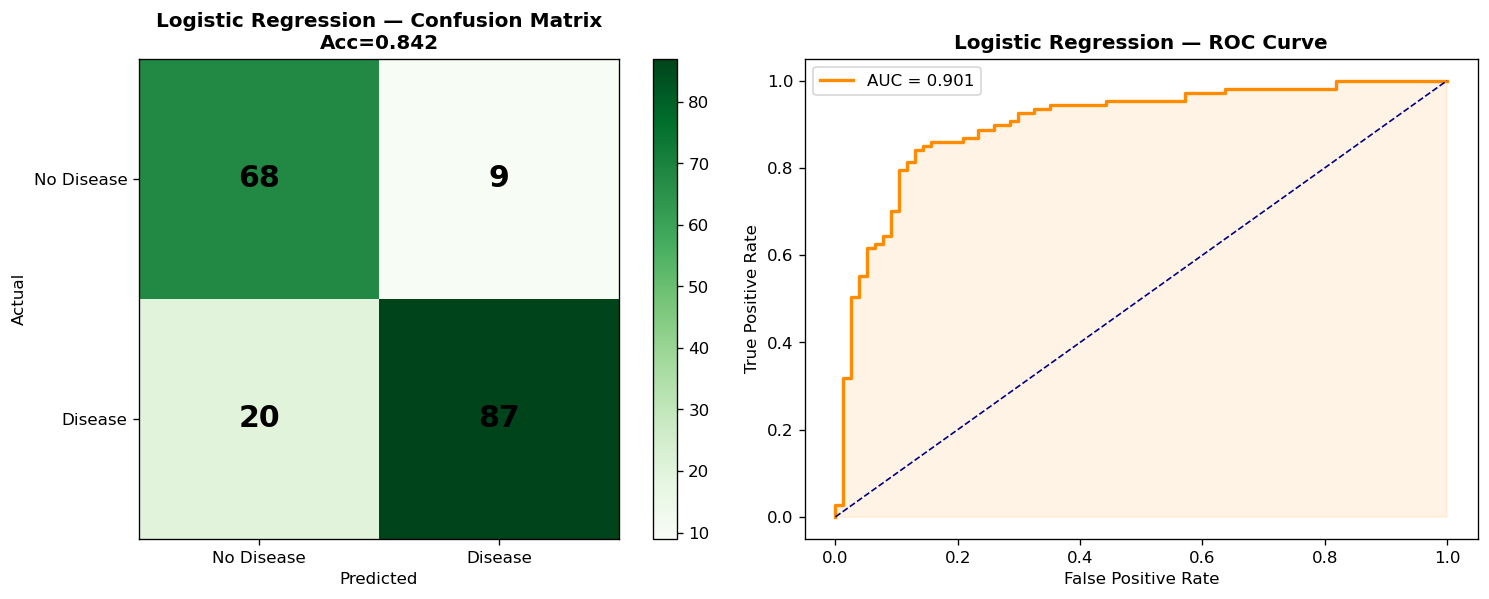

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Confusion Matrix ---
cm_log = confusion_matrix(y_test, y_pred_log)
im = axes[0].imshow(cm_log, cmap='Greens')
plt.colorbar(im, ax=axes[0])
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, str(cm_log[i, j]),
                     ha='center', va='center',
                     fontsize=18, fontweight='bold', color='black')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['No Disease', 'Disease'])
axes[0].set_yticks([0, 1])
axes[0].set_yticklabels(['No Disease', 'Disease'])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title(f'Logistic Regression — Confusion Matrix\nAcc={log_acc:.3f}',
                  fontweight='bold')

# --- ROC Curve ---
fpr, tpr, _ = roc_curve(y_test, y_prob_log)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {log_auc:.3f}')
axes[1].plot([0, 1], [0, 1], 'navy', linestyle='--', lw=1)
axes[1].fill_between(fpr, tpr, alpha=0.1, color='darkorange')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Logistic Regression — ROC Curve', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

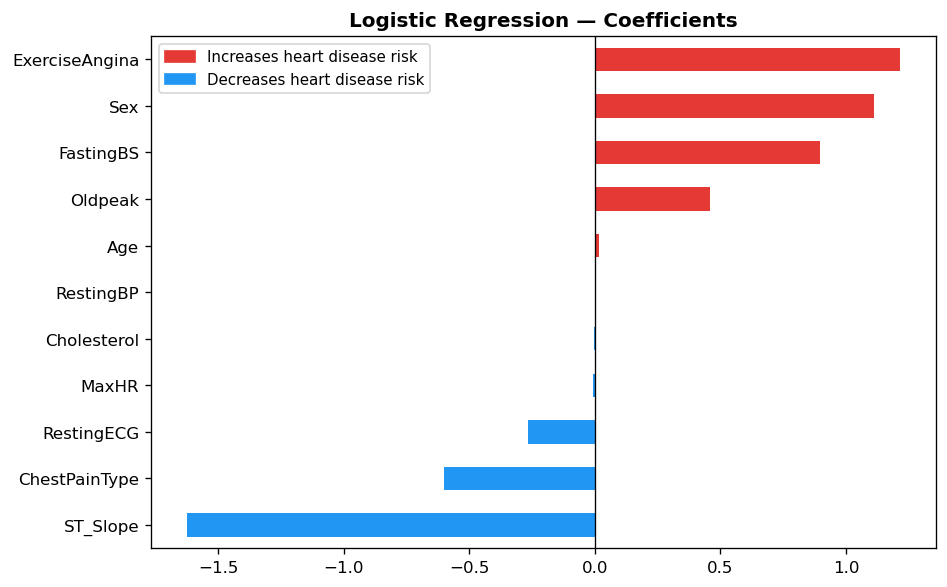

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
coef_log = pd.Series(logreg.coef_[0], index=feature_names).sort_values()
bar_colors = ['#E53935' if c > 0 else '#2196F3' for c in coef_log]
coef_log.plot(kind='barh', ax=ax, color=bar_colors)
ax.axvline(0, color='black', lw=0.8)
red_p  = mpatches.Patch(color='#E53935', label='Increases heart disease risk')
blue_p = mpatches.Patch(color='#2196F3', label='Decreases heart disease risk')
ax.legend(handles=[red_p, blue_p], fontsize=9)
ax.set_title('Logistic Regression — Coefficients', fontweight='bold')
plt.tight_layout()
plt.show()

In [14]:
nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)
y_prob_nb = nb.predict_proba(X_test)[:, 1]

nb_acc = accuracy_score(y_test, y_pred_nb)
nb_auc = roc_auc_score(y_test, y_prob_nb)

print(f"Accuracy : {nb_acc:.4f}")
print(f"AUC-ROC  : {nb_auc:.4f}")
print()
print(classification_report(y_test, y_pred_nb, target_names=['No Disease', 'Disease']))

Accuracy : 0.8424
AUC-ROC  : 0.9090

              precision    recall  f1-score   support

  No Disease       0.79      0.84      0.82        77
     Disease       0.88      0.84      0.86       107

    accuracy                           0.84       184
   macro avg       0.84      0.84      0.84       184
weighted avg       0.84      0.84      0.84       184



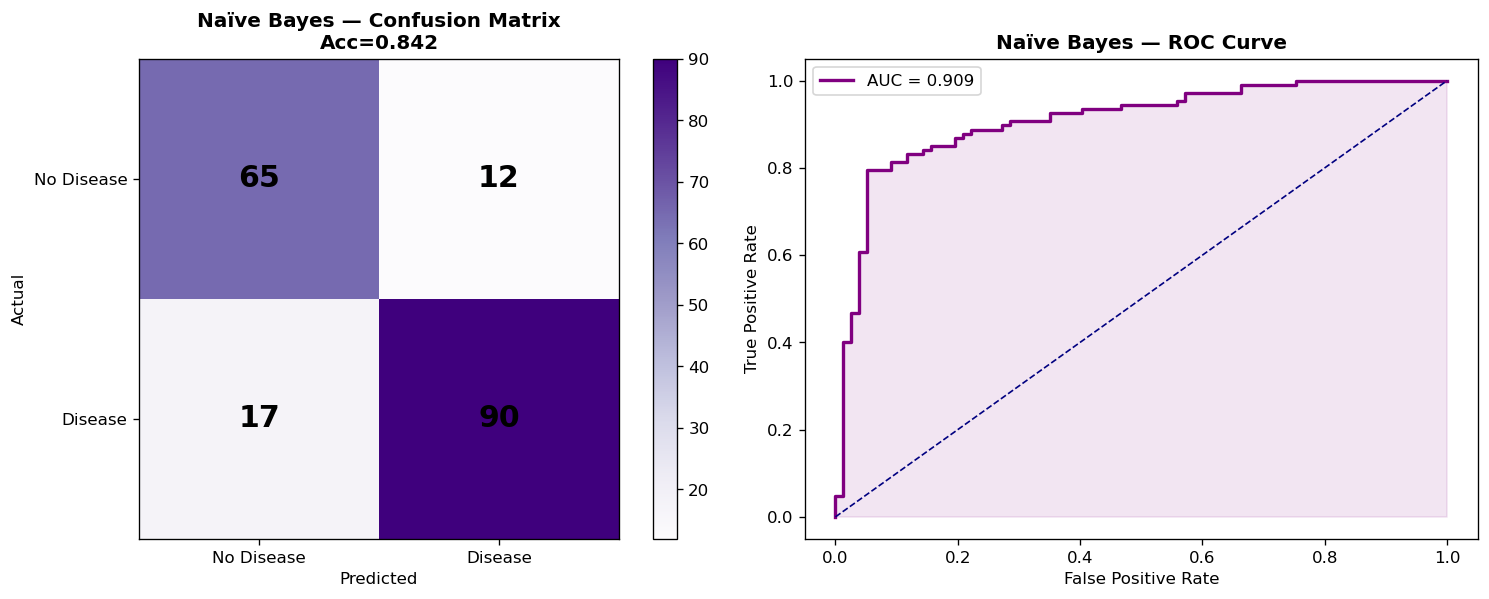

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Confusion Matrix ---
cm_nb = confusion_matrix(y_test, y_pred_nb)
im = axes[0].imshow(cm_nb, cmap='Purples')
plt.colorbar(im, ax=axes[0])
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, str(cm_nb[i, j]),
                     ha='center', va='center',
                     fontsize=18, fontweight='bold', color='black')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['No Disease', 'Disease'])
axes[0].set_yticks([0, 1])
axes[0].set_yticklabels(['No Disease', 'Disease'])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title(f'Naïve Bayes — Confusion Matrix\nAcc={nb_acc:.3f}', fontweight='bold')

# --- ROC Curve ---
fpr_nb, tpr_nb, _ = roc_curve(y_test, y_prob_nb)
axes[1].plot(fpr_nb, tpr_nb, color='purple', lw=2, label=f'AUC = {nb_auc:.3f}')
axes[1].plot([0, 1], [0, 1], 'navy', linestyle='--', lw=1)
axes[1].fill_between(fpr_nb, tpr_nb, alpha=0.1, color='purple')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Naïve Bayes — ROC Curve', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

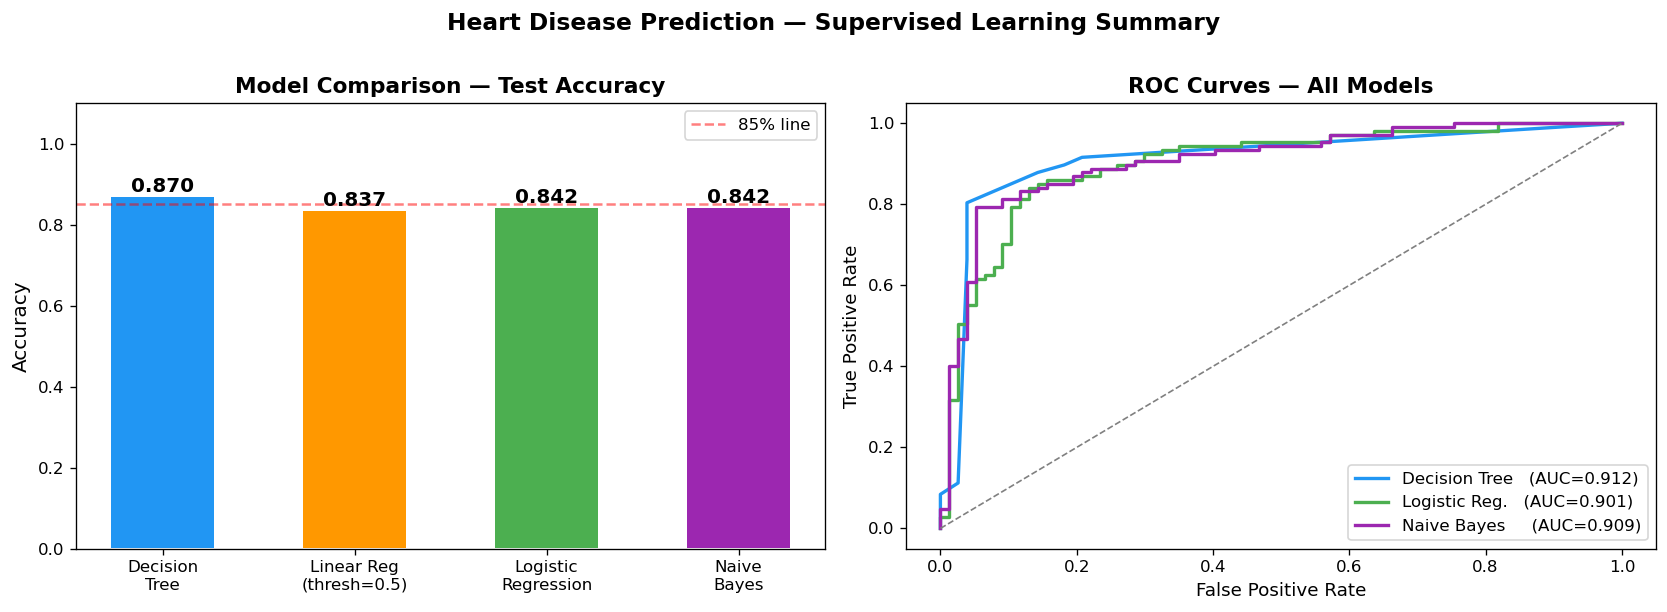

In [16]:
fpr_dt, tpr_dt, _ = roc_curve(y_test, dt.predict_proba(X_test)[:, 1])
auc_dt = roc_auc_score(y_test, dt.predict_proba(X_test)[:, 1])

model_names = ['Decision\nTree', 'Linear Reg\n(thresh=0.5)', 'Logistic\nRegression', 'Naive\nBayes']
accs   = [accuracy_score(y_test, y_pred_dt), lr_acc, log_acc, nb_acc]
colors = ['#2196F3', '#FF9800', '#4CAF50', '#9C27B0']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Accuracy Bar ---
bars = axes[0].bar(model_names, accs, color=colors, edgecolor='white', linewidth=1.2, width=0.55)
axes[0].set_ylim(0, 1.1)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Model Comparison — Test Accuracy', fontweight='bold', fontsize=13)
for bar, acc in zip(bars, accs):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                 f'{acc:.3f}', ha='center', fontweight='bold', fontsize=12)
axes[0].axhline(0.85, color='red', linestyle='--', alpha=0.5, label='85% line')
axes[0].legend()

# --- Combined ROC ---
axes[1].plot(fpr_dt, tpr_dt, color='#2196F3', lw=2, label=f'Decision Tree   (AUC={auc_dt:.3f})')
axes[1].plot(fpr,    tpr,    color='#4CAF50', lw=2, label=f'Logistic Reg.   (AUC={log_auc:.3f})')
axes[1].plot(fpr_nb, tpr_nb, color='#9C27B0', lw=2, label=f'Naive Bayes     (AUC={nb_auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'grey', linestyle='--', lw=1)
axes[1].set_xlabel('False Positive Rate', fontsize=11)
axes[1].set_ylabel('True Positive Rate', fontsize=11)
axes[1].set_title('ROC Curves — All Models', fontweight='bold', fontsize=13)
axes[1].legend(fontsize=10)

plt.suptitle('Heart Disease Prediction — Supervised Learning Summary',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [17]:
summary = pd.DataFrame({
    'Model': ['Decision Tree', 'Linear Regression', 'Logistic Regression', 'Naive Bayes'],
    'Accuracy': [f'{accuracy_score(y_test, y_pred_dt):.4f}',
                 f'{lr_acc:.4f}',
                 f'{log_acc:.4f}',
                 f'{nb_acc:.4f}'],
    'AUC-ROC':  [f'{auc_dt:.4f}',
                 'N/A (regression)',
                 f'{log_auc:.4f}',
                 f'{nb_auc:.4f}'],
    'Notes': [
        'Best accuracy; interpretable tree structure',
        'Not ideal for binary targets; MSE=0.1373, R2=0.4358',
        'Best probability calibration; high AUC',
        'Fastest to train; highest AUC'
    ]
})
summary

,Model,Accuracy,AUC-ROC,Notes
0,Decision Tree,0.8696,0.9121,Best accuracy; interpretable tree structure
1,Linear Regression,0.8370,N/A (regression),"Not ideal for binary targets; MSE=0.1373, R2=0..."
2,Logistic Regression,0.8424,0.9013,Best probability calibration; high AUC
3,Naive Bayes,0.8424,0.9090,Fastest to train; highest AUC


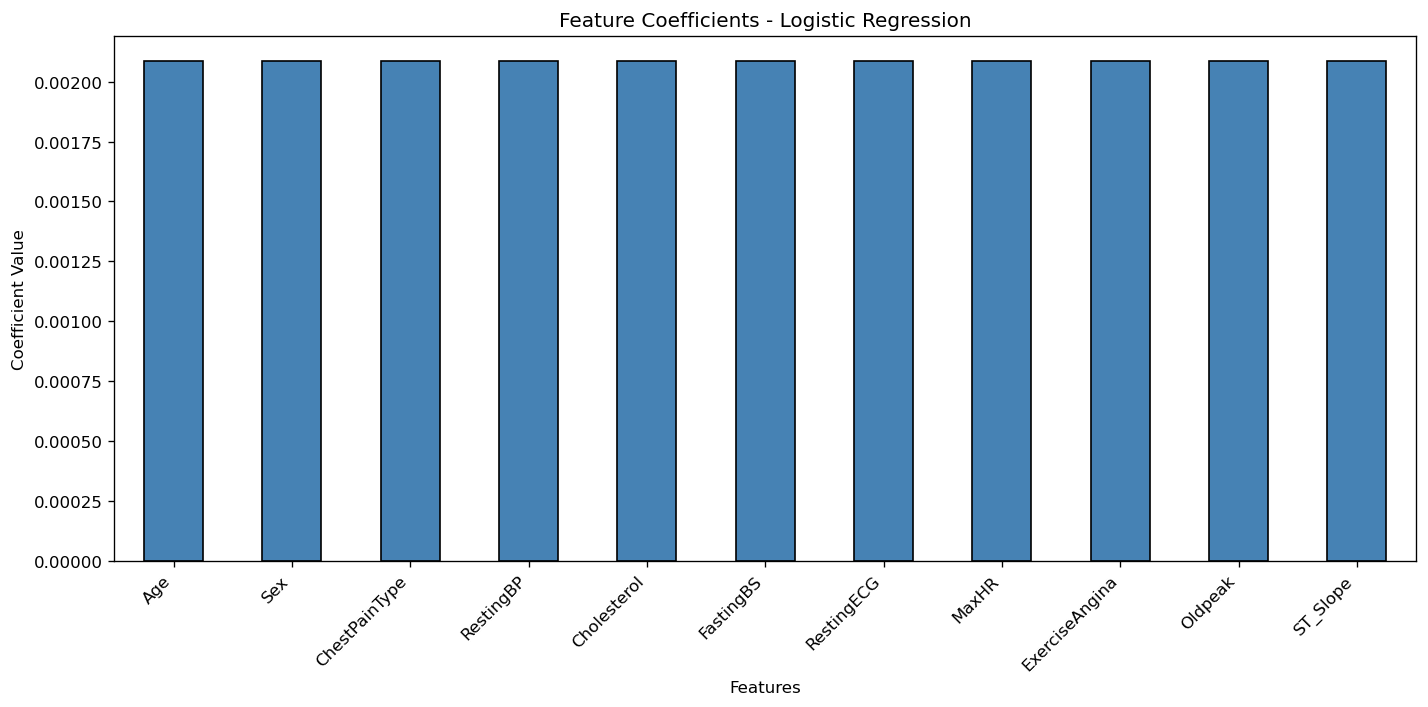


Top 5 Positive Predictors:
Age              0.002086
Sex              0.002086
ChestPainType    0.002086
RestingBP        0.002086
Cholesterol      0.002086
dtype: float64

Top 5 Negative Predictors:
RestingECG        0.002086
MaxHR             0.002086
ExerciseAngina    0.002086
Oldpeak           0.002086
ST_Slope          0.002086
dtype: float64


In [18]:
coefficients = pd.Series(lr.coef_[0], index=X.columns)
coefficients = coefficients.sort_values(ascending=False)

plt.figure(figsize=(12, 6))
coefficients.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Feature Coefficients - Logistic Regression')
plt.xlabel('Features')
plt.ylabel('Coefficient Value')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nTop 5 Positive Predictors:")
print(coefficients.head())
print("\nTop 5 Negative Predictors:")
print(coefficients.tail())

In [32]:
from sklearn.model_selection import GridSearchCV

param_grid_nb = {
    'var_smoothing': [1e-11, 1e-10, 1e-9, 1e-8, 1e-7, 1e-6, 1e-5]
}

grid_nb = GridSearchCV(
    GaussianNB(),
    param_grid_nb,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_nb.fit(X_train, y_train)

print("Best var_smoothing:", grid_nb.best_params_)
print(f"Best CV Accuracy  : {grid_nb.best_score_:.4f}")

Best var_smoothing: {'var_smoothing': 1e-07}
Best CV Accuracy  : 0.8504


In [33]:
best_nb = grid_nb.best_estimator_
y_pred_best_nb = best_nb.predict(X_test)
y_prob_best_nb = best_nb.predict_proba(X_test)[:, 1]

print(f"Default NB Accuracy : {nb_acc:.4f}")
print(f"Tuned   NB Accuracy : {accuracy_score(y_test, y_pred_best_nb):.4f}")
print()
print(f"Default NB AUC : {nb_auc:.4f}")
print(f"Tuned   NB AUC : {roc_auc_score(y_test, y_prob_best_nb):.4f}")
print()
print(classification_report(y_test, y_pred_best_nb, target_names=['No Disease', 'Disease']))

Default NB Accuracy : 0.8424
Tuned   NB Accuracy : 0.8732

Default NB AUC : 0.9090
Tuned   NB AUC : 0.9331

              precision    recall  f1-score   support

  No Disease       0.82      0.88      0.85       112
     Disease       0.91      0.87      0.89       164

    accuracy                           0.87       276
   macro avg       0.87      0.87      0.87       276
weighted avg       0.88      0.87      0.87       276



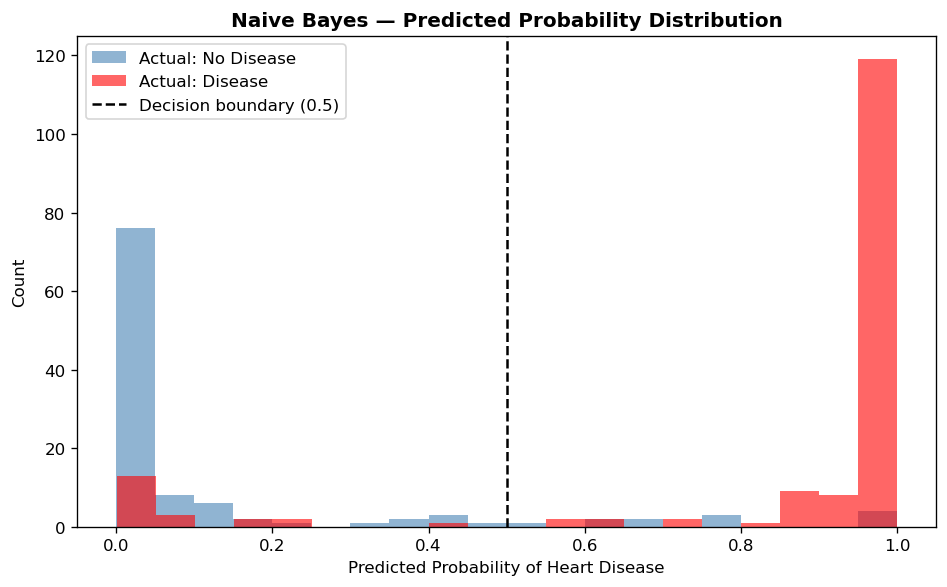

In [34]:
fig, ax = plt.subplots(figsize=(8, 5))

# Probabilities for actual class 0
ax.hist(y_prob_nb[y_test == 0], bins=20, alpha=0.6,
        color='steelblue', label='Actual: No Disease')

# Probabilities for actual class 1
ax.hist(y_prob_nb[y_test == 1], bins=20, alpha=0.6,
        color='red', label='Actual: Disease')

ax.axvline(0.5, color='black', linestyle='--', label='Decision boundary (0.5)')
ax.set_xlabel('Predicted Probability of Heart Disease')
ax.set_ylabel('Count')
ax.set_title('Naive Bayes — Predicted Probability Distribution', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

In [35]:
# Decision Tree
dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = (lr.predict(X_test) >= 0.5).astype(int)

# Logistic Regression
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train, y_train)
y_pred_log = logreg.predict(X_test)
y_prob_log = logreg.predict_proba(X_test)[:, 1]

# Naive Bayes
nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)
y_prob_nb = nb.predict_proba(X_test)[:, 1]

print("All models trained ✅")

All models trained ✅


In [36]:
from sklearn.metrics import precision_score, recall_score, f1_score

model_names = ['Decision Tree', 'Linear Regression', 'Logistic Regression', 'Naive Bayes']
predictions = [y_pred_dt, y_pred_lr, y_pred_log, y_pred_nb]

results = []
for name, y_pred in zip(model_names, predictions):
    results.append({
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall'   : round(recall_score(y_test, y_pred), 4),
        'F1 Score' : round(f1_score(y_test, y_pred), 4)
    })

summary_df = pd.DataFrame(results)
summary_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Decision Tree,0.8370,0.8563,0.8720,0.8640
1,Linear Regression,0.8587,0.9195,0.8354,0.8754
2,Logistic Regression,0.8623,0.9200,0.8415,0.8790
3,Naive Bayes,0.8732,0.9108,0.8720,0.8910


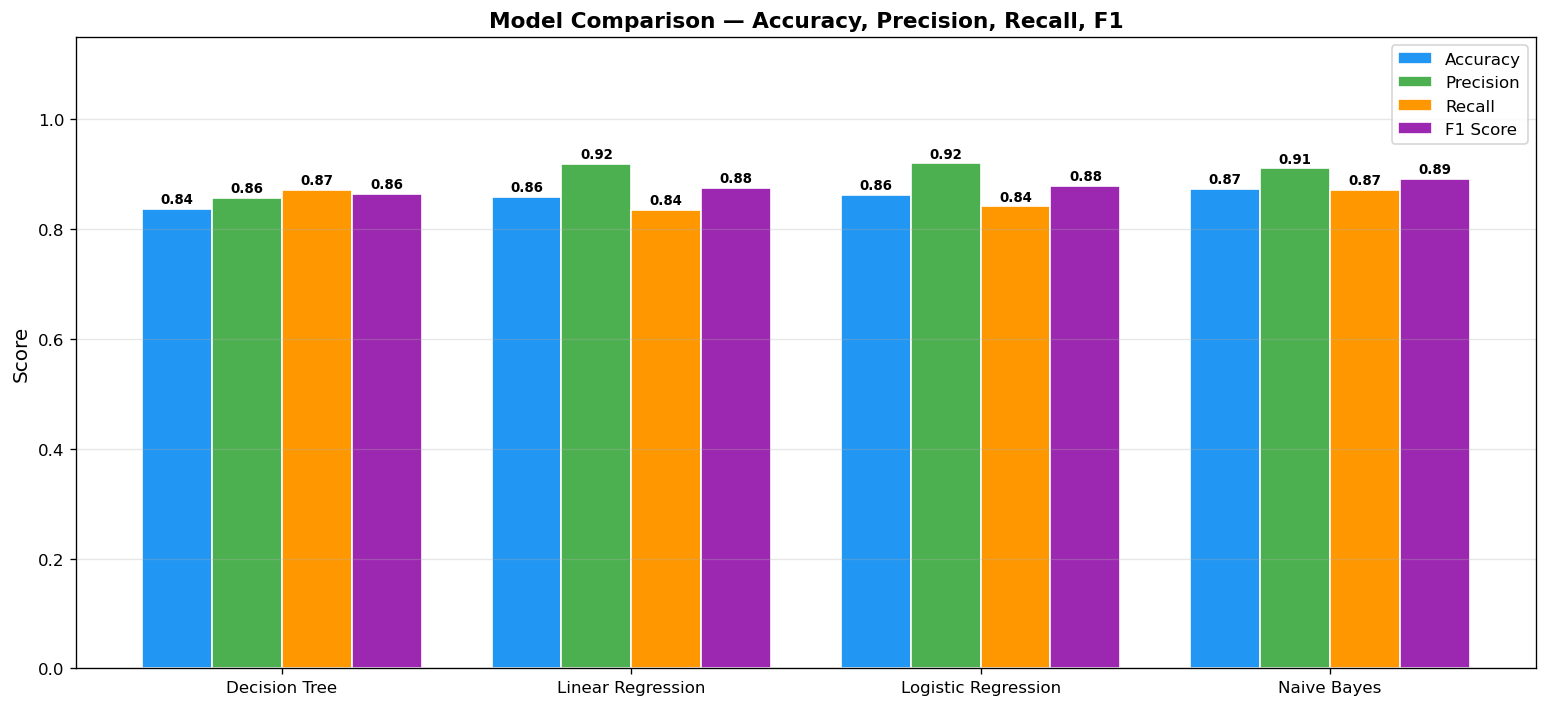

In [37]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
colors  = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']
x = np.arange(len(model_names))
width = 0.2

fig, ax = plt.subplots(figsize=(13, 6))

for i, (metric, color) in enumerate(zip(metrics, colors)):
    values = summary_df[metric].values
    bars = ax.bar(x + i * width, values, width=width, label=metric, color=color, edgecolor='white')
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{val:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(model_names, fontsize=10)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Comparison — Accuracy, Precision, Recall, F1', fontweight='bold', fontsize=13)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

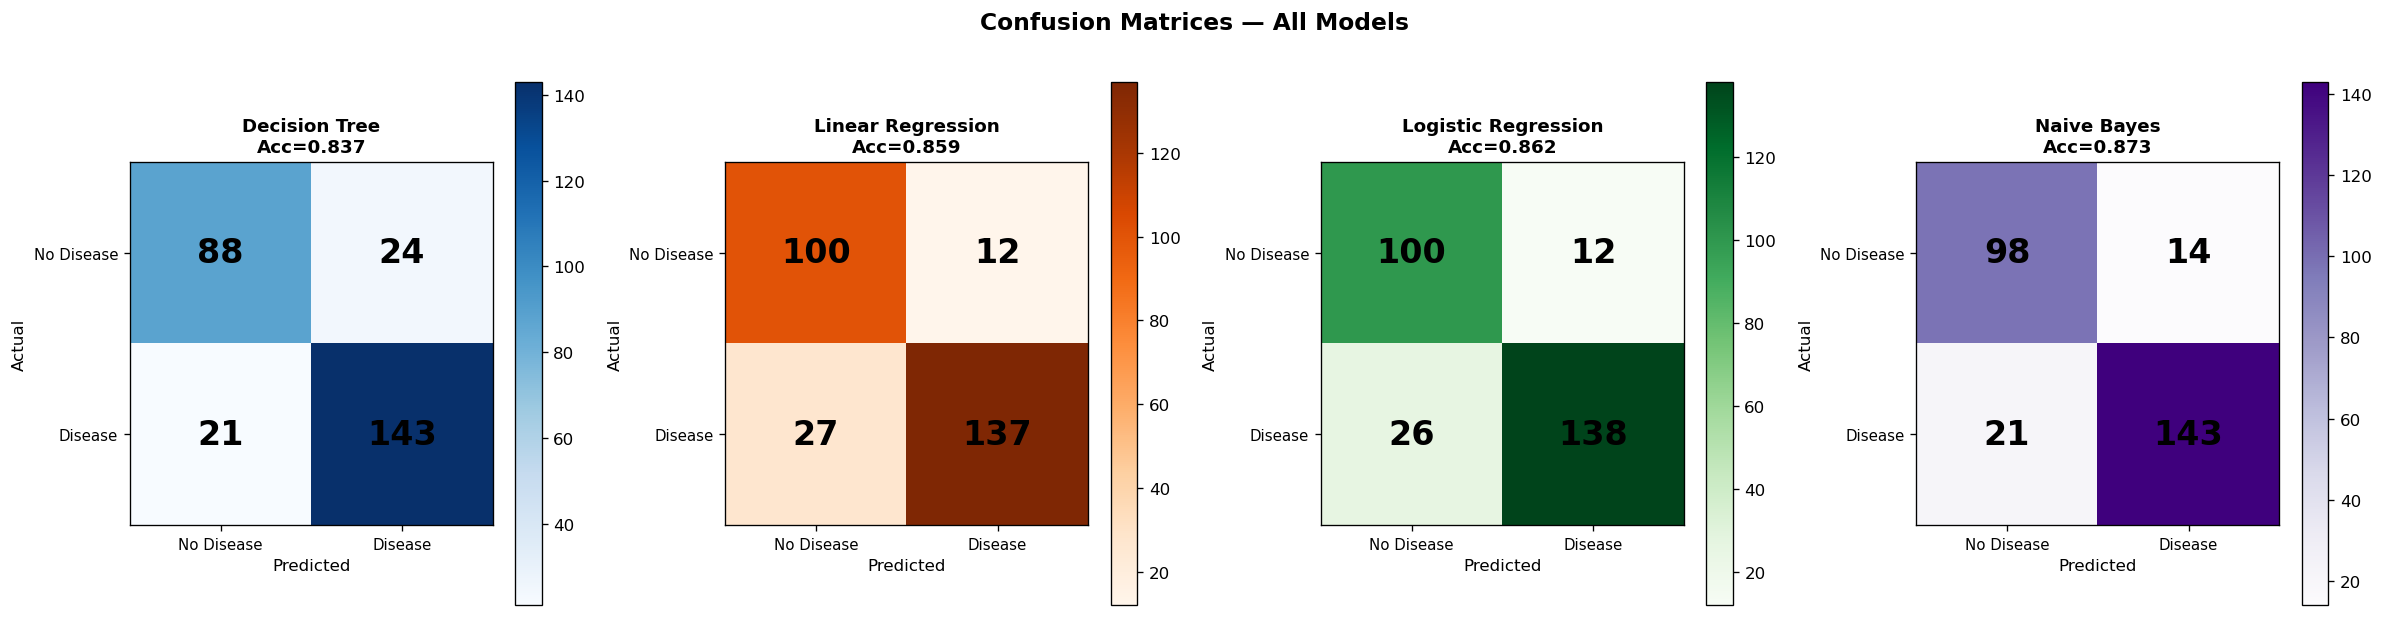

In [38]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

all_cms    = [confusion_matrix(y_test, y_pred_dt),
              confusion_matrix(y_test, y_pred_lr),
              confusion_matrix(y_test, y_pred_log),
              confusion_matrix(y_test, y_pred_nb)]

all_titles = ['Decision Tree', 'Linear Regression', 'Logistic Regression', 'Naive Bayes']
cmaps      = ['Blues', 'Oranges', 'Greens', 'Purples']

for ax, cm, title, cmap in zip(axes, all_cms, all_titles, cmaps):
    im = ax.imshow(cm, cmap=cmap)
    plt.colorbar(im, ax=ax)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]),
                    ha='center', va='center',
                    fontsize=20, fontweight='bold', color='black')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['No Disease', 'Disease'], fontsize=9)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['No Disease', 'Disease'], fontsize=9)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    acc = accuracy_score(y_test, [y_pred_dt, y_pred_lr, y_pred_log, y_pred_nb][list(all_titles).index(title)])
    ax.set_title(f'{title}\nAcc={acc:.3f}', fontweight='bold', fontsize=11)

plt.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

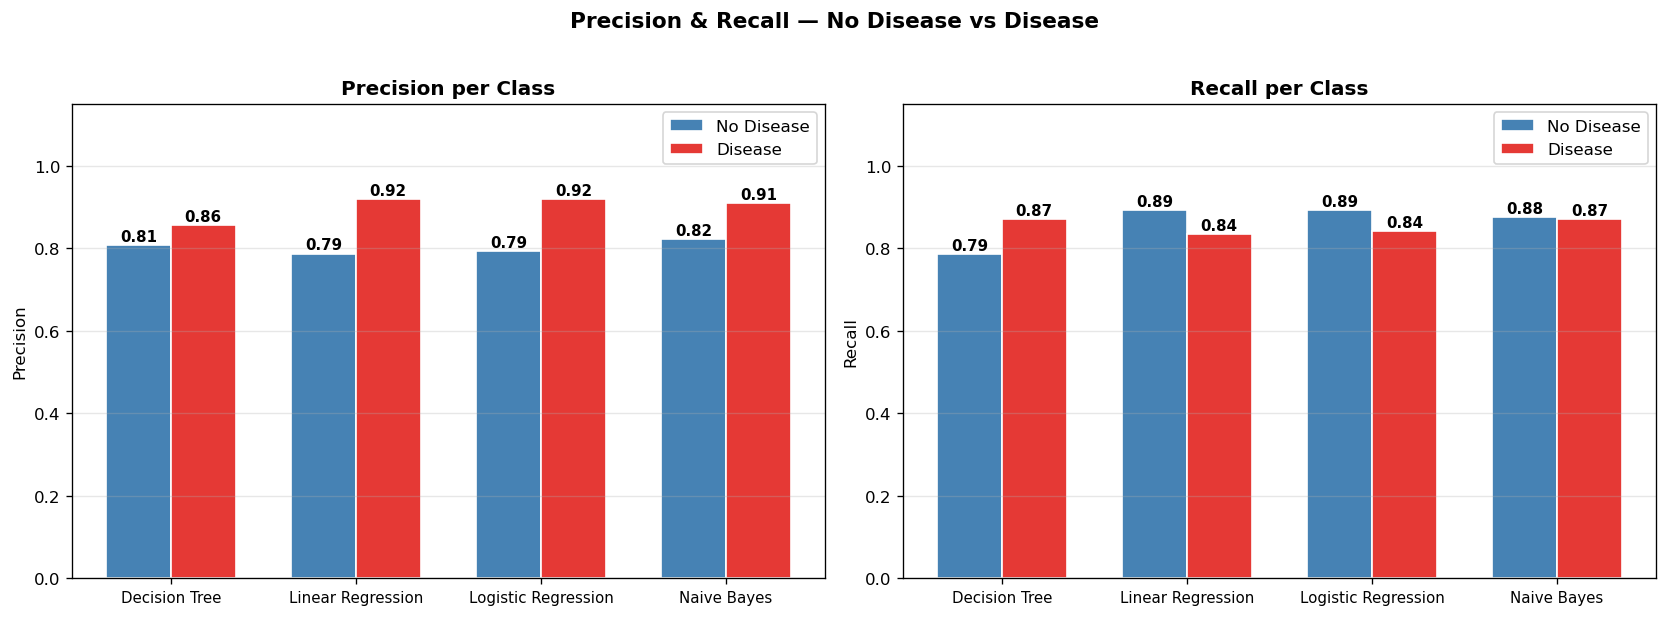

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(model_names))
width = 0.35

# --- Precision per class ---
prec_no_disease = [precision_score(y_test, p, pos_label=0) for p in predictions]
prec_disease    = [precision_score(y_test, p, pos_label=1) for p in predictions]

axes[0].bar(x - width/2, prec_no_disease, width, label='No Disease', color='steelblue', edgecolor='white')
axes[0].bar(x + width/2, prec_disease,    width, label='Disease',    color='#E53935',   edgecolor='white')
for i, (v1, v2) in enumerate(zip(prec_no_disease, prec_disease)):
    axes[0].text(i - width/2, v1 + 0.01, f'{v1:.2f}', ha='center', fontsize=9, fontweight='bold')
    axes[0].text(i + width/2, v2 + 0.01, f'{v2:.2f}', ha='center', fontsize=9, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names, fontsize=9)
axes[0].set_ylim(0, 1.15)
axes[0].set_title('Precision per Class', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Precision')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# --- Recall per class ---
rec_no_disease = [recall_score(y_test, p, pos_label=0) for p in predictions]
rec_disease    = [recall_score(y_test, p, pos_label=1) for p in predictions]

axes[1].bar(x - width/2, rec_no_disease, width, label='No Disease', color='steelblue', edgecolor='white')
axes[1].bar(x + width/2, rec_disease,    width, label='Disease',    color='#E53935',   edgecolor='white')
for i, (v1, v2) in enumerate(zip(rec_no_disease, rec_disease)):
    axes[1].text(i - width/2, v1 + 0.01, f'{v1:.2f}', ha='center', fontsize=9, fontweight='bold')
    axes[1].text(i + width/2, v2 + 0.01, f'{v2:.2f}', ha='center', fontsize=9, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(model_names, fontsize=9)
axes[1].set_ylim(0, 1.15)
axes[1].set_title('Recall per Class', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Recall')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Precision & Recall — No Disease vs Disease', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()